# Step 2 - Time-series cross-validation for ITS

**Goal:** understand why ITS needs expanding-window cross-validation (not k-fold), and how every knob of `time_series_cv()` in `its2s.cross_validation` affects the fold layout.

This step sits between data splitting (step 1) and hyperparameter tuning (step 3). A correctly configured CV routine is the *objective function* that `tune_model()` will optimize against. Get this wrong and every downstream hyperparameter is tuned to leak.

Sections:
- **2a.** Why not k-fold? Temporal leakage made visible.
- **2b.** Expanding-window fold layout: `min_train_obs`, `test_obs`, `n_folds`.
- **2c.** `skip_obs`: the inter-fold gap.
- **2d.** `cv_end_date`: keeping CV folds out of the held-out evaluation window.
- **2e.** Reading `CVResult`: per-fold and aggregate metrics.

We use the packaged `data/dummy_data.csv` (2018-01-01 to 2022-04-25; intervention 2022-03-15, 42-day post-intervention window).


In [1]:
%matplotlib inline

import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

from its2s.cross_validation import time_series_cv

OUT_DIR = Path.cwd() / 'figures'
OUT_DIR.mkdir(exist_ok=True)

DATA = Path('data/dummy_data.csv')
INTERVENTION = pd.Timestamp('2022-03-15')
TEST_DAYS = 90

df = pd.read_csv(DATA, parse_dates=['ds']).sort_values('ds').reset_index(drop=True)
pre_df = df[df['ds'] < INTERVENTION].reset_index(drop=True)
print(f'Full series:        {len(df)} rows, {df.ds.min().date()} -> {df.ds.max().date()}')
print(f'Pre-intervention:   {len(pre_df)} rows, up to {pre_df.ds.max().date()}')
print(f'Intervention date:  {INTERVENTION.date()}')


Full series:        1576 rows, 2018-01-01 -> 2022-04-25
Pre-intervention:   1534 rows, up to 2022-03-14
Intervention date:  2022-03-15


## 2a. Why not k-fold? Temporal leakage

**Leakage** occurs when a model is trained on information it would not have access to in real use, making cross-validation estimates too optimistic. For time series, the most common source is temporal: a model that trains on future data will look accurate when evaluated against the past, but will fail when actually deployed.

Standard k-fold CV assumes observations are exchangeable — any row can be a training row for any fold. Time series violate this. If you randomly assign fold membership, a fold can easily train on rows from *after* its validation window: the model peeks at the future.

Two concrete failure modes:

1. **Distributional leakage.** Time series often shift over time — trends change, seasonal patterns evolve. If training rows come from *after* the test window, the model learns from a regime it should not yet know about. CV scores look good, but only because the model was cheating.

2. **Autocorrelation leakage.** Consecutive daily values are highly correlated: day *t* and day *t+1* carry nearly redundant information. If day *t+1* is in the training set while day *t* is in the test set, the model has seen a near-perfect hint about *t* during training. Validation accuracy is inflated — not because the model generalizes well, but because "training" and "test" share information across their boundary.

Expanding-window CV avoids both by construction: every fold's training window ends strictly before its validation window begins.

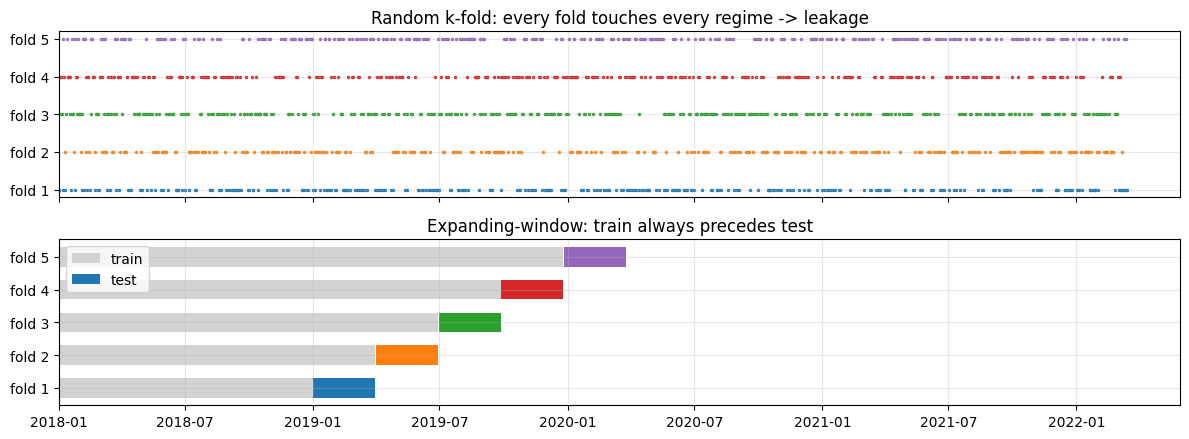

In [2]:
# Visualize the two layouts side by side.
n = len(pre_df)
rng = np.random.default_rng(42)
kfold_assign = rng.integers(0, 5, size=n)

fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
colors = plt.cm.tab10(np.arange(5))

# Random k-fold
for k in range(5):
    mask = kfold_assign == k
    axes[0].scatter(pre_df.loc[mask, 'ds'], [k]*mask.sum(),
                    s=2, c=[colors[k]], label=f'fold {k+1}')
axes[0].set_yticks(range(5)); axes[0].set_yticklabels([f'fold {i+1}' for i in range(5)])
axes[0].set_title('Random k-fold: every fold touches every regime -> leakage')
axes[0].grid(True, alpha=0.3)

# Expanding-window
min_train, test_d = 365, 90
for i in range(5):
    ts = min_train + i*test_d
    te = ts + test_d
    if te > n: break
    axes[1].barh(i, pre_df['ds'].iloc[ts-1] - pre_df['ds'].iloc[0],
                 left=pre_df['ds'].iloc[0], height=0.6, color='lightgray', label='train' if i==0 else None)
    axes[1].barh(i, pre_df['ds'].iloc[te-1] - pre_df['ds'].iloc[ts],
                 left=pre_df['ds'].iloc[ts], height=0.6, color=colors[i], label='test' if i==0 else None)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels([f'fold {i+1}' for i in range(5)])
axes[1].set_title('Expanding-window: train always precedes test')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig(OUT_DIR / 'step2a_kfold_vs_expanding.png', dpi=150)
display(fig)


## 2b. Fold layout

The key insight in `cross_validation.py` is its **fixed, non-overlapping layout**:

```
fold i test window starts at: min_train_obs + i * (test_obs + skip_obs)
fold i test window ends at:   test_start + test_obs
```

Setting `skip_obs=0` gives adjacent folds. An alternate approach would be to use step-based implementation using `available_for_testing // n_folds` as the spacing, which will silently cause **overlapping** test windows whenever that spacing falls below `test_obs`. This layout is overlap-free by construction.


In [3]:
# Visualize the fold geometry directly, without fitting any model.
def fold_windows(pre_df, min_train_obs, test_obs, n_folds, skip_obs=0):
    folds = []
    for i in range(n_folds):
        ts_idx = min_train_obs + i*(test_obs + skip_obs)
        te_idx = ts_idx + test_obs
        if te_idx > len(pre_df): break
        folds.append({
            'fold': i+1,
            'train_start': pre_df['ds'].iloc[0],
            'train_end':   pre_df['ds'].iloc[ts_idx-1],
            'test_start':  pre_df['ds'].iloc[ts_idx],
            'test_end':    pre_df['ds'].iloc[te_idx-1],
            'n_train':     ts_idx,
            'n_test':      test_obs,
        })
    return pd.DataFrame(folds)

layout = fold_windows(pre_df, min_train_obs=365, test_obs=90, n_folds=5, skip_obs=0)
display(layout)


,fold,train_start,train_end,test_start,test_end,n_train,n_test
0,1,2018-01-01,2018-12-31,2019-01-01,2019-03-31,365,90
1,2,2018-01-01,2019-03-31,2019-04-01,2019-06-29,455,90
2,3,2018-01-01,2019-06-29,2019-06-30,2019-09-27,545,90
3,4,2018-01-01,2019-09-27,2019-09-28,2019-12-26,635,90
4,5,2018-01-01,2019-12-26,2019-12-27,2020-03-25,725,90


## 2c. The inter-fold gap

`skip_obs` inserts a buffer between consecutive test windows, and helps in achieving **independence between folds**. Adjacent daily test windows share short-run autocorrelation. A gap reduces the covariance between per-fold errors, making `std_rmse` a more honest measure of variability.

Below we contrast `skip_obs=0` and `skip_obs=90` geometrically. Note how the higher value pushes later folds further out in time, so you may need more data or fewer folds.

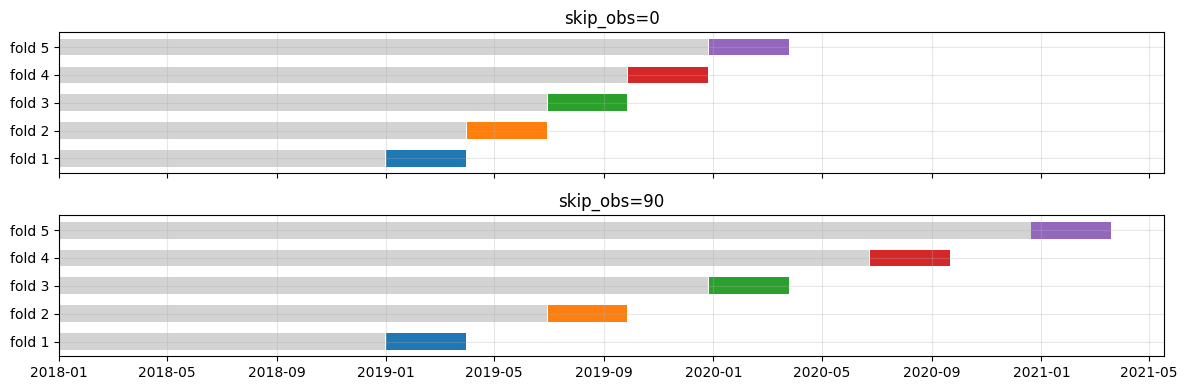

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for ax, skip in zip(axes, [0, 90]):
    layout = fold_windows(pre_df, min_train_obs=365, test_obs=90, n_folds=5, skip_obs=skip)
    for _, row in layout.iterrows():
        i = row['fold'] - 1
        ax.barh(i, row['train_end'] - row['train_start'],
                left=row['train_start'], height=0.6, color='lightgray')
        ax.barh(i, row['test_end'] - row['test_start'],
                left=row['test_start'], height=0.6, color=colors[i])
    ax.set_yticks(range(5)); ax.set_yticklabels([f'fold {i+1}' for i in range(5)])
    ax.set_title(f'skip_obs={skip}')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'step2c_skip_obs.png', dpi=150)
display(fig)

## 2d. Avoiding test-window leakage

`run_single_its()` reserves a held-out evaluation window just before the intervention (by default the last 20% of pre-intervention observations; step 1 used an explicit 365-day window). If CV folds were drawn from all pre-intervention data, a fold could land on those same rows -- so any hyperparameter tuned on CV would be implicitly tuned to fit the evaluation window, leaking skill.

`cv_end_date` is the cap that prevents this, and it is leakage-safe by default (GH #40): `cv_end_date=None` derives the boundary row-exactly from the run's split config (the `periods` section) by asking `prepare_splits` where the test window starts -- exact for every split method and series frequency. Pass CV and tuning the same config/overrides the run will use, and the derived cap matches the run's actual window.

Guard rails: `cv_end_date > intervention_date` raises `ValueError`; `cv_end_date=intervention_date` explicitly restores the old use-all-pre-intervention behavior for users who know what they're doing.

Below we set an explicit 90-day cap so the before/after geometry is easy to see.

intervention_date: 2022-03-15
cv_end_date:       2021-12-15 (= intervention - 90 days)


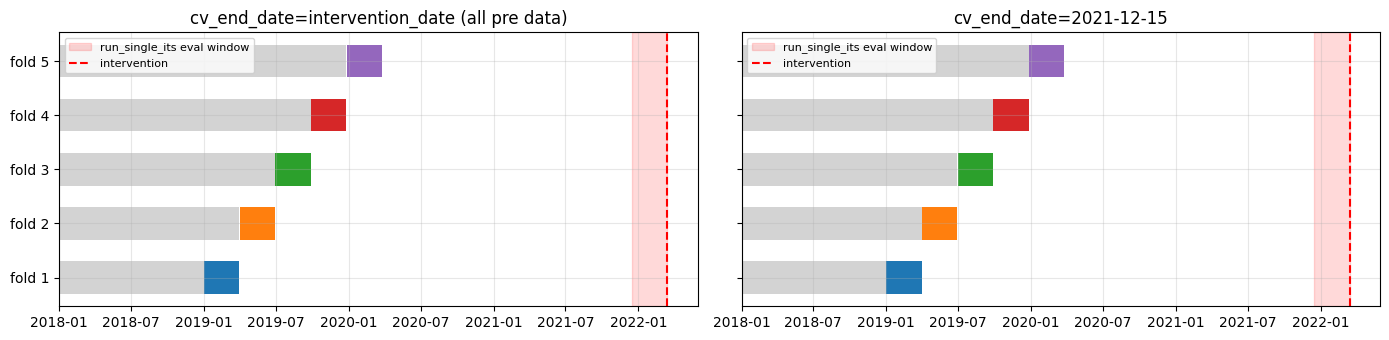

In [5]:
cv_end = INTERVENTION - pd.Timedelta(days=TEST_DAYS)
print(f'intervention_date: {INTERVENTION.date()}')
print(f'cv_end_date:       {cv_end.date()} (= intervention - {TEST_DAYS} days)')

# Visualize: uncapped (left) vs capped (right); the cap is explicit here
# so the geometry is easy to see
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
for ax, cap, label in [(axes[0], None, 'cv_end_date=intervention_date (all pre data)'),
                       (axes[1], cv_end, f'cv_end_date={cv_end.date()}')]:
    upper = cap if cap is not None else INTERVENTION
    cv_df = pre_df[pre_df['ds'] < upper].reset_index(drop=True)
    layout = fold_windows(cv_df, min_train_obs=365, test_obs=90, n_folds=5, skip_obs=0)
    for _, row in layout.iterrows():
        i = row['fold'] - 1
        ax.barh(i, row['train_end'] - row['train_start'], left=row['train_start'],
                height=0.6, color='lightgray')
        ax.barh(i, row['test_end'] - row['test_start'], left=row['test_start'],
                height=0.6, color=colors[i])
    ax.axvspan(INTERVENTION - pd.Timedelta(days=TEST_DAYS), INTERVENTION,
               color='red', alpha=0.15, label='run_single_its eval window')
    ax.axvline(INTERVENTION, color='red', linestyle='--', label='intervention')
    ax.set_title(label)
    ax.set_yticks(range(5)); ax.set_yticklabels([f'fold {i+1}' for i in range(5)])
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step2d_cv_end_date.png', dpi=150)
display(fig)


## 2e. Reading CVResult

Now run `time_series_cv()` end-to-end on ARIMA (fast to fit) and inspect the returned `CVResult`. Each fold yields a `CVFoldResult` with per-fold RMSE/MAE/MAPE/MASE (the seasonal-naive ratio at the resolved period m); the aggregate returns mean and std for RMSE/MAE across folds, plus mean MAPE.

If a fold raises inside `.fit()` or `.predict()`, `time_series_cv` logs a warning, drops that fold, and continues with the rest. An all-folds-failed run raises `RuntimeError`.


In [6]:
# End-to-end CV. cv_end_date defaults to the start of the run's held-out
# test window, derived from the config's periods split (GH #40).
cv_result = time_series_cv(
    df=df,
    intervention_date=INTERVENTION,
    model_name='arima',
    n_folds=5,
    test_obs=90,
    min_train_obs=365,
    skip_obs=0,
)
print(cv_result.summary())
print(f'derived cv_end_date: {cv_result.cv_end_date.date()}')

# Per-fold table.
fold_rows = [
    {'fold': f.fold, 'train_end': f.train_end.date(),
     'test_start': f.test_start.date(), 'test_end': f.test_end.date(),
     'n_train': f.n_train, 'n_test': f.n_test,
     'rmse': f.metrics.rmse, 'mae': f.metrics.mae,
     'mape': f.metrics.mape, 'mase': f.metrics.mase}
    for f in cv_result.folds
]
display(pd.DataFrame(fold_rows))


Cross-validation: arima (5 folds)
  RMSE: 5.9424 +/- 1.3631
  MAE:  5.0999 +/- 1.1803
  MAPE: 9.77%
derived cv_end_date: 2021-05-12


,fold,train_end,test_start,test_end,n_train,n_test,rmse,mae,mape,mase
0,1,2018-12-31,2019-01-01,2019-03-31,365,90,7.324191,6.474988,10.912312,2.991908
1,2,2019-03-31,2019-04-01,2019-06-29,455,90,7.017581,5.941870,10.679316,2.707527
2,3,2019-06-29,2019-06-30,2019-09-27,545,90,5.940511,5.061784,11.712157,2.269170
3,4,2019-09-27,2019-09-28,2019-12-26,635,90,5.537524,4.557435,9.729859,2.026656
4,5,2019-12-26,2019-12-27,2020-03-25,725,90,3.892427,3.463656,5.825065,1.536905


## Key takeaways

1. **Expanding-window, not k-fold.** Training window always ends strictly before the validation window. No temporal leakage by construction.
2. **Fold geometry is deterministic.** `test_start = min_train_obs + i*(test_obs + skip_obs)`. No overlap at `skip_obs=0`; a controlled gap at `skip_obs>0`.
3. **`skip_obs`** controls independence between folds. Use `skip_obs=365` to keep adjacent folds well-separated, reducing fold-to-fold correlation and giving a more conservative estimate of model variance.
4. **`cv_end_date`** is the bridge to step 1: by default it is derived from the run's split config, so CV folds never touch the `run_single_its()` evaluation window; pass `cv_end_date=intervention_date` to deliberately use all pre-intervention data.
5. **`CVResult`** is the objective function that step 3 (`tune_model`) will minimize. Understand its geometry before you tune.